In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [42]:
import datetime

def get_user_input():
    stock_name = input("Enter the stock name (e.g., AAPL, TSLA, GOOGL): ").strip()
    
    while True:
        start_date = input("Enter the start date (YYYY-MM-DD): ").strip()
        try:
            start_date = datetime.datetime.strptime(start_date, "%Y-%m-%d")
            break
        except ValueError:
            print("Invalid date format. Please enter the date in YYYY-MM-DD format.")

    while True:
        end_date = input("Enter the end date (YYYY-MM-DD): ").strip()
        try:
            end_date = datetime.datetime.strptime(end_date, "%Y-%m-%d")
            if end_date > start_date:
                break
            else:
                print("End date must be after the start date.")
        except ValueError:
            print("Invalid date format. Please enter the date in YYYY-MM-DD format.")

    
    timeframes = ["daily", "weekly", "monthly"]
    print(f"Available timeframes: {', '.join(timeframes)}")
    while True:
        timeframe = input("Enter the timeframe (daily/weekly/monthly): ").strip().lower()
        if timeframe in timeframes:
            break
        else:
            print("Invalid timeframe. Please choose from daily, weekly, or monthly.")
    
    return stock_name, start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d"), timeframe


In [43]:
stock_name, start_date, end_date, timeframe = get_user_input()

Enter the stock name (e.g., AAPL, TSLA, GOOGL):  GOOGL
Enter the start date (YYYY-MM-DD):  2010-1-1
Enter the end date (YYYY-MM-DD):  2020-12-31


Available timeframes: daily, weekly, monthly


Enter the timeframe (daily/weekly/monthly):  weekly


In [44]:
def download_historical_data(symbol, start_date, end_date, timeframe):
    timeframe_map = {
        "daily": "1d",
        "weekly": "1wk",
        "monthly": "1mo"
    }
    
    yf_interval = timeframe_map.get(timeframe)

    data = yf.download(tickers=symbol, start=start_date, end=end_date, interval=yf_interval)
    return data


In [45]:
data = download_historical_data(stock_name, start_date, end_date, timeframe)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2010-01-01,14.813667,15.696604,14.777513,15.632770,613541844
2010-01-08,14.707694,15.071989,14.309987,14.761303,1099986912
2010-01-15,14.536394,14.800203,14.268846,14.794716,771611616
2010-01-22,13.322326,14.227702,13.230317,14.075601,909861228
2010-01-29,13.135068,13.517066,13.104647,13.427053,673897428


In [46]:
def plot_closing_price(data, symbol):
    if 'Close' not in data.columns:
        print(f"No 'Close' column found in the data for {symbol}.")
        return
    
    plt.figure(figsize=(10, 6))
    plt.plot(data.index, data['Close'], label=f'{symbol} Closing Price', color='green')
    plt.title(f'{symbol} Closing Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Closing Price (USD)')
    plt.legend()
    plt.grid()
    plt.show()

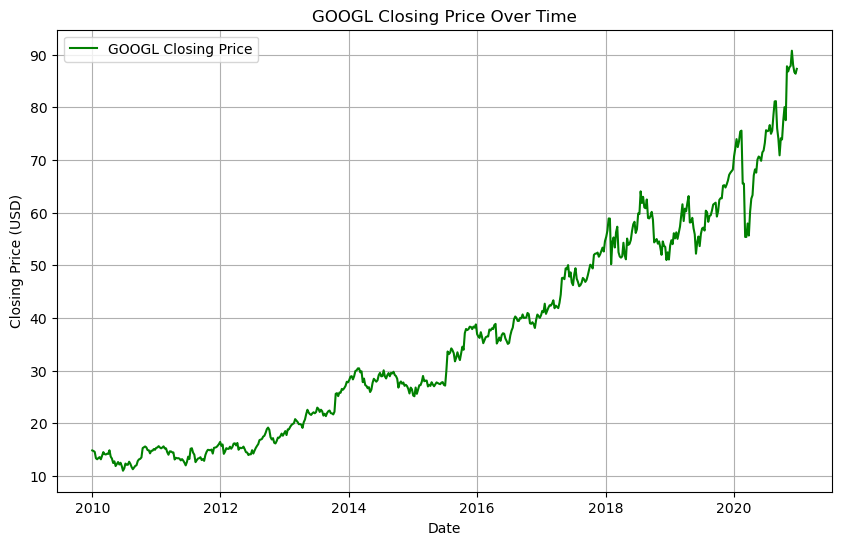

In [47]:
plot_closing_price(data, stock_name)

In [48]:
def calculate_macd(data, short_window=12, long_window=26, signal_window=9):
    data['EMA_Short'] = data['Close'].ewm(span=short_window, adjust=False).mean()
    data['EMA_Long'] = data['Close'].ewm(span=long_window, adjust=False).mean()

    data['MACD'] = data['EMA_Short'] - data['EMA_Long']

    data['Signal_Line'] = data['MACD'].ewm(span=signal_window, adjust=False).mean()
    return data

In [49]:
def calculate_rsi(data, period=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    return data


In [50]:

def plot_macd(data, symbol):
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['MACD'], label='MACD', color='blue')
    plt.plot(data.index, data['Signal_Line'], label='Signal Line', color='red')
    plt.title(f'{symbol} MACD')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid()
    plt.show()


In [51]:

def plot_rsi(data, symbol):
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['RSI'], label='RSI', color='purple')
    plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
    plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
    plt.title(f'{symbol} RSI')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid()
    plt.show()

In [52]:
calculate_macd(data)

Price,Close,High,Low,Open,Volume,EMA_Short,EMA_Long,MACD,Signal_Line
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,,,,
Date,,,,,,,,,
2010-01-01,14.813667,15.696604,14.777513,15.632770,613541844,14.813667,14.813667,0.000000,0.000000
2010-01-08,14.707694,15.071989,14.309987,14.761303,1099986912,14.797364,14.805817,-0.008454,-0.001691
2010-01-15,14.536394,14.800203,14.268846,14.794716,771611616,14.757215,14.785860,-0.028646,-0.007082
2010-01-22,13.322326,14.227702,13.230317,14.075601,909861228,14.536462,14.677450,-0.140988,-0.033863
2010-01-29,13.135068,13.517066,13.104647,13.427053,673897428,14.320863,14.563200,-0.242336,-0.075558
...,...,...,...,...,...,...,...,...,...
2020-11-27,90.762985,91.858509,87.076345,87.908328,138710000,83.111321,78.570151,4.541170,3.411026
2020-12-04,88.063263,91.144592,86.363424,90.682271,123184000,83.873158,79.273344,4.599814,3.648783


In [53]:
calculate_rsi(data)

Price,Close,High,Low,Open,Volume,EMA_Short,EMA_Long,MACD,Signal_Line,RSI
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,,,,,
Date,,,,,,,,,,
2010-01-01,14.813667,15.696604,14.777513,15.632770,613541844,14.813667,14.813667,0.000000,0.000000,NaN
2010-01-08,14.707694,15.071989,14.309987,14.761303,1099986912,14.797364,14.805817,-0.008454,-0.001691,NaN
2010-01-15,14.536394,14.800203,14.268846,14.794716,771611616,14.757215,14.785860,-0.028646,-0.007082,NaN
2010-01-22,13.322326,14.227702,13.230317,14.075601,909861228,14.536462,14.677450,-0.140988,-0.033863,NaN
2010-01-29,13.135068,13.517066,13.104647,13.427053,673897428,14.320863,14.563200,-0.242336,-0.075558,NaN
...,...,...,...,...,...,...,...,...,...,...
2020-11-27,90.762985,91.858509,87.076345,87.908328,138710000,83.111321,78.570151,4.541170,3.411026,62.811489
2020-12-04,88.063263,91.144592,86.363424,90.682271,123184000,83.873158,79.273344,4.599814,3.648783,58.551652


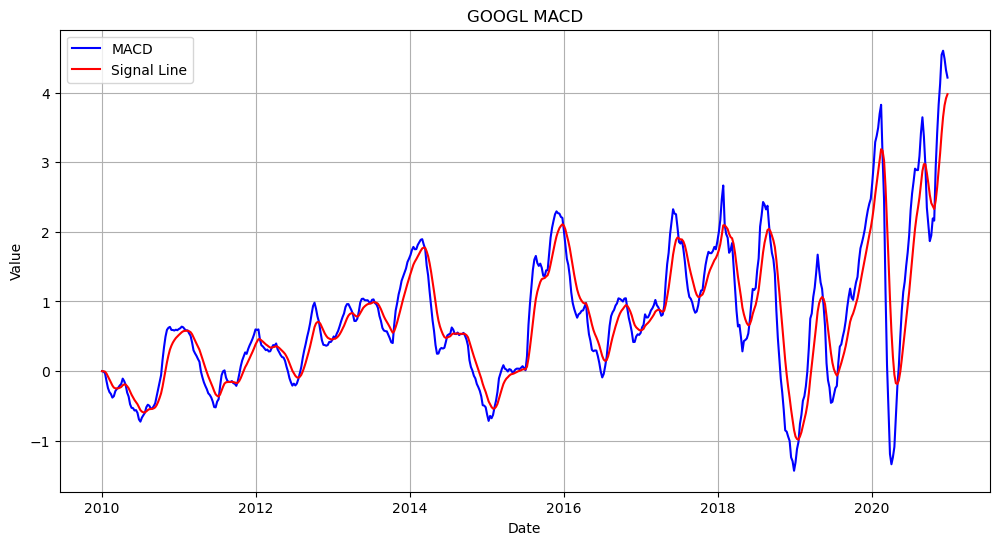

In [54]:
plot_macd(data, stock_name)

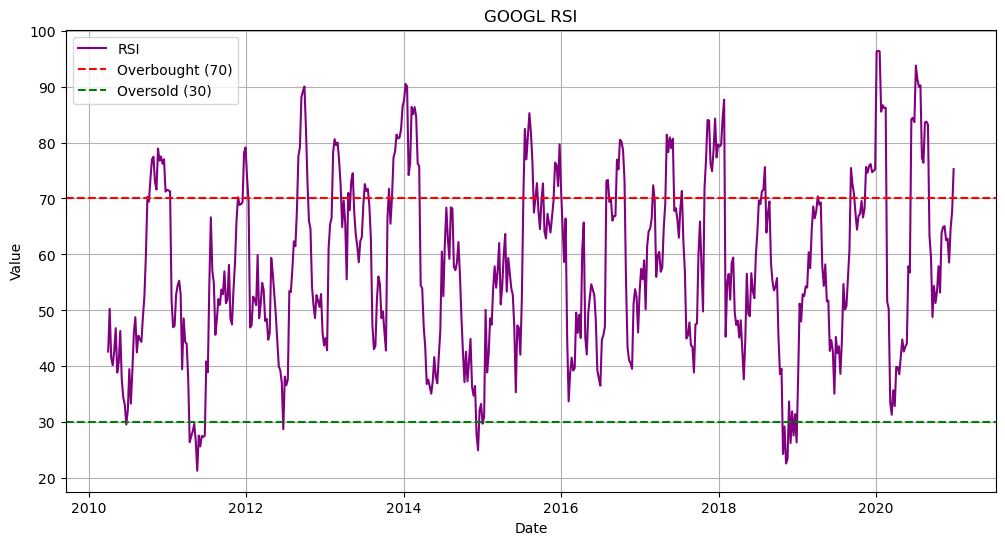

In [55]:
plot_rsi(data, stock_name)

In [56]:
from sklearn.preprocessing import MinMaxScaler

def normalize_data(df, columns):
    scaler = MinMaxScaler(feature_range=(0, 1))
    df[columns] = scaler.fit_transform(df[columns])
    return df

columns_to_normalize = ['Close', 'Volume', 'EMA_Short', 'EMA_Long', 'MACD', 'Signal_Line']

df_normalized = normalize_data(data, columns_to_normalize)

In [57]:
df_normalized.head()

Price,Close,High,Low,Open,Volume,EMA_Short,EMA_Long,MACD,Signal_Line,RSI
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,,,,,
Date,,,,,,,,,,
2010-01-01,0.048307,15.696604,14.777513,15.632770,0.432087,0.039101,0.034925,0.237096,0.198218,NaN
2010-01-08,0.046979,15.071989,14.309987,14.761303,0.824834,0.038877,0.034810,0.235694,0.197877,NaN
2010-01-15,0.044833,14.800203,14.268846,14.794716,0.559710,0.038328,0.034519,0.232345,0.196790,NaN
2010-01-22,0.029620,14.227702,13.230317,14.075601,0.671330,0.035308,0.032934,0.213712,0.191390,NaN
2010-01-29,0.027273,13.517066,13.104647,13.427053,0.480817,0.032358,0.031264,0.196903,0.182982,NaN


In [58]:
def create_sequences(data, feature_columns, target_column, time_steps=60):
    
    features = []
    targets = []
    for i in range(len(data) - time_steps):

        feature_window = data[feature_columns].iloc[i:i + time_steps].values
        
        target_value = data[target_column].iloc[i + time_steps]
        features.append(feature_window)
        targets.append(target_value)
    return np.array(features), np.array(targets)

In [59]:
feature_columns = ['Close', 'Volume', 'EMA_Short', 'EMA_Long', 'MACD', 'Signal_Line']
target_column = 'Close'

X, y = create_sequences(df_normalized, feature_columns, target_column)

In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def create_lstm_model(input_shape, dropout_rate=0.2):
    model = Sequential()
    
    model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    
    model.add(LSTM(64, activation='relu', return_sequences=False))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(1))  

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [61]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and compile the LSTM model
input_shape = (X_train.shape[1], X_train.shape[2])  
model = create_lstm_model(input_shape)

# Model summary
model.summary()

C:\Users\SAHIL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,265 (200.25 KB)

 Trainable params: 51,265 (200.25 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - loss: 0.0601 - mae: 0.1899 - val_loss: 0.0294 - val_mae: 0.1621
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0072 - mae: 0.0680 - val_loss: 0.0100 - val_mae: 0.0675
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - loss: 0.0032 - mae: 0.0411 - val_loss: 0.0069 - val_mae: 0.0693
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0023 - mae: 0.0351 - val_loss: 0.0105 - val_mae: 0.0926
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0023 - mae: 0.0352 - val_loss: 0.0096 - val_mae: 0.0882
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0020 - mae: 0.0326 - val_loss: 0.0066 - val_mae: 0.0705
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0018 - mae: 0.0316 - val_loss: 0.0060 - val_mae: 0.0662
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0021 - mae: 0.0321 - val_loss: 0.0094 - val_mae: 0.0867
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0

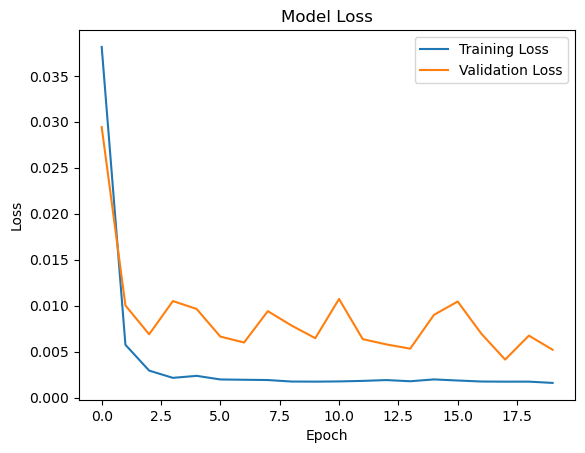

In [63]:
# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



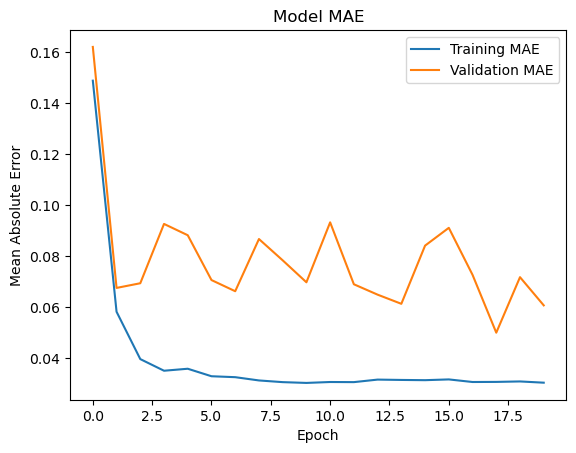

In [64]:
# Plot training & validation MAE (Mean Absolute Error)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()



In [65]:
def predict_next_units(model, data, feature_columns, time_steps, n_predictions):
    predictions = []

    # Start with the last sequence of data
    last_sequence = data[feature_columns].iloc[-time_steps:].values

    for _ in range(n_predictions):
        # Reshape the last sequence to match the model's input shape
        input_data = np.expand_dims(last_sequence, axis=0)

        # Predict the next value (assuming the target is a single value like 'Close')
        predicted_value = model.predict(input_data, verbose=0)[0][0]

        # Append the prediction
        predictions.append(predicted_value)

        # Create a new sequence by adding the predicted value and removing the oldest
        new_row = np.copy(last_sequence[-1])  # Copy the last row to use as a base
        new_row[0] = predicted_value  # Update the target column (e.g., 'Close') with the prediction

        last_sequence = np.append(last_sequence[1:], [new_row], axis=0)

    return predictions


In [70]:
# Parameters
n_predictions = 15
time_steps = X_train.shape[1]  # The sequence length used in training
feature_columns = ['Close', 'Volume', 'EMA_Short', 'EMA_Long', 'MACD', 'Signal_Line']  # Adjust to match your data

# Generate predictions
predicted_values = predict_next_units(model, df_normalized, feature_columns, time_steps, n_predictions)

# Denormalize predictions (if normalization was applied)
scaler = MinMaxScaler(feature_range=(0, 1))  # Replace with your actual scaler
scaler.fit(data[['Close']])  # Fit scaler on the original 'Close' column

predicted_values_denormalized = scaler.inverse_transform(np.array(predicted_values).reshape(-1, 1))

# Display predictions
print("Next 15 predicted values (normalized):", predicted_values)
print("Next 15 predicted values (denormalized):", predicted_values_denormalized)


Next 15 predicted values (normalized): [0.9392455, 0.94938827, 0.9584592, 0.9666221, 0.97401404, 0.9807424, 0.9868932, 0.9925352, 0.9977237, 1.0025047, 1.0069014, 1.0109386, 1.0146397, 1.0180295, 1.0211316]
Next 15 predicted values (denormalized): [[0.9392455 ]
 [0.94938827]
 [0.9584592 ]
 [0.9666221 ]
 [0.97401404]
 [0.9807424 ]
 [0.9868932 ]
 [0.9925352 ]
 [0.9977237 ]
 [1.0025047 ]
 [1.0069014 ]
 [1.0109386 ]
 [1.0146397 ]
 [1.0180295 ]
 [1.0211316 ]]


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


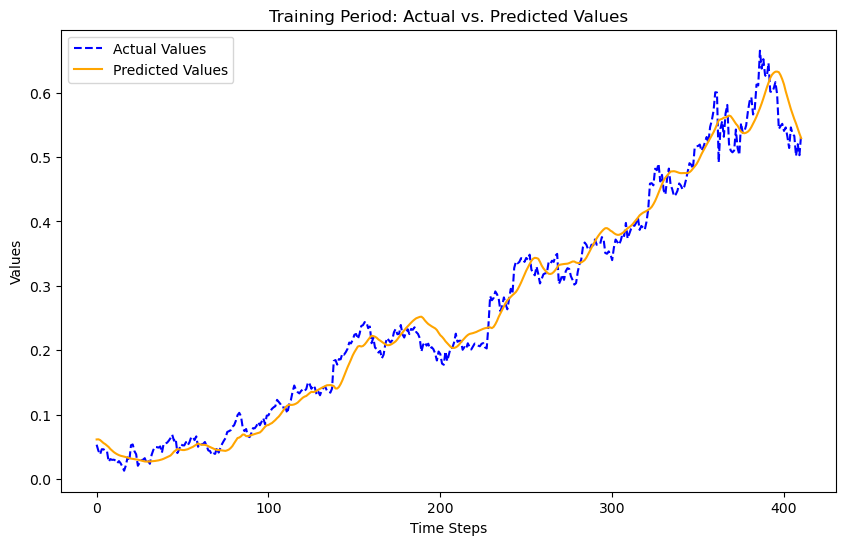

In [71]:
y_train_pred = model.predict(X_train)

plt.figure(figsize=(10, 6))
plt.plot(y_train, label="Actual Values", color="blue", linestyle="--")
plt.plot(y_train_pred, label="Predicted Values", color="orange")
plt.title("Training Period: Actual vs. Predicted Values")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


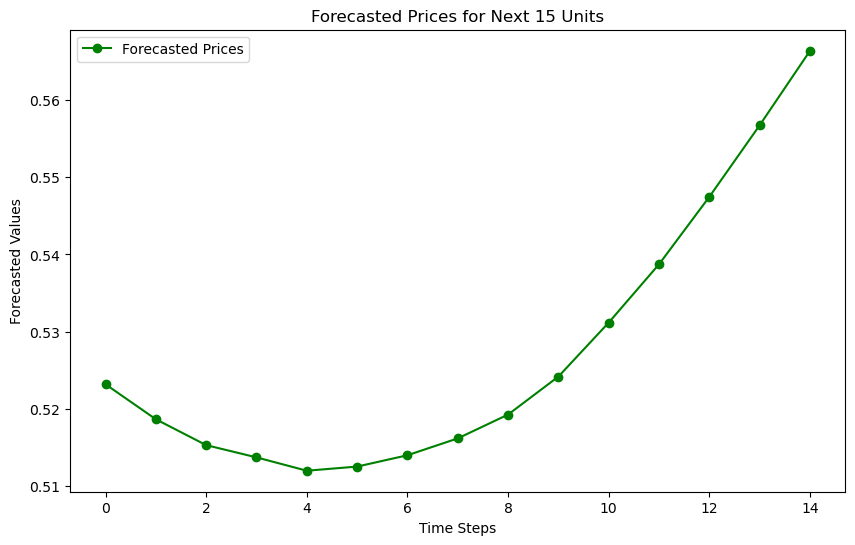

In [72]:
forecasted_prices = model.predict(X_test[:15])  # Replace [:15] if your test set is longer

plt.figure(figsize=(10, 6))
plt.plot(range(15), forecasted_prices, marker="o", color="green", label="Forecasted Prices")
plt.title("Forecasted Prices for Next 15 Units")
plt.xlabel("Time Steps")
plt.ylabel("Forecasted Values")
plt.legend()
plt.show()

In [74]:
ss_res = np.sum((y_train - y_train_pred)**2)  # Residual sum of squares
ss_tot = np.sum((y_train - np.mean(y_train))**2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)
print(f"R² Score for Training Period: {r2:.4f}")


R² Score for Training Period: 0.9796
